In [107]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [108]:
df = pd.read_csv('ford.csv')

In [109]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [110]:
df.shape

(17966, 9)

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [112]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [113]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

# EDA

<Axes: xlabel='price', ylabel='Count'>

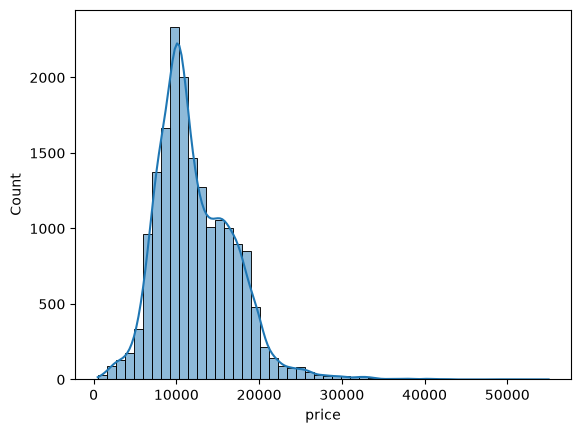

In [114]:
sns.histplot(df['price'],bins=50,kde=True)

<Axes: >

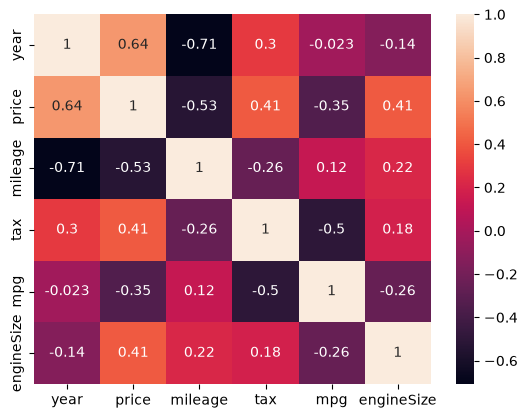

In [115]:
sns.heatmap(df.corr(numeric_only=True), annot = True)

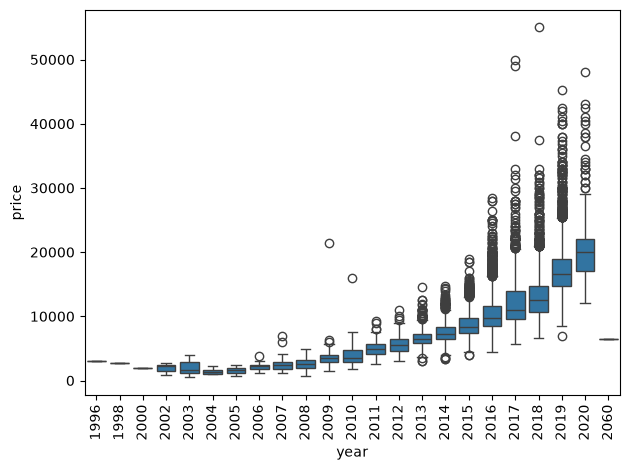

In [116]:
sns.boxplot(data=df, x = 'year', y = 'price')
plt.xticks(rotation=90)
plt.tight_layout()

<Axes: xlabel='mileage', ylabel='price'>

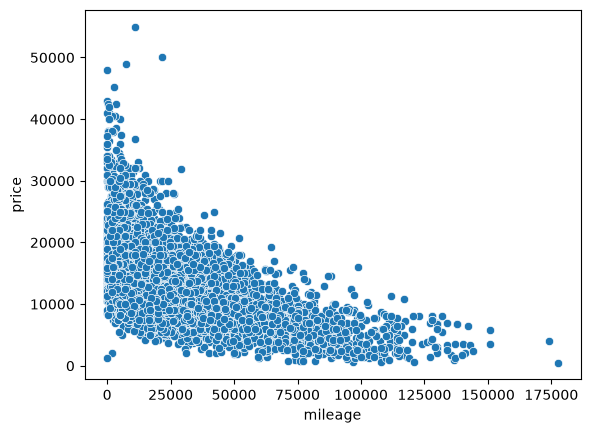

In [117]:
sns.scatterplot(data=df, x='mileage', y = 'price')

<Axes: xlabel='engineSize', ylabel='price'>

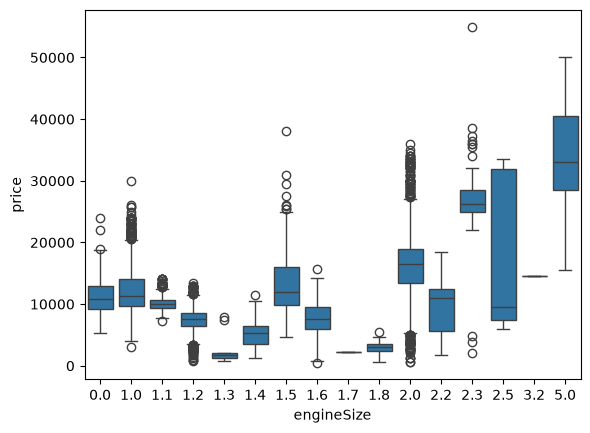

In [118]:
sns.boxplot(x='engineSize', y='price', data=df)

<Axes: xlabel='transmission', ylabel='price'>

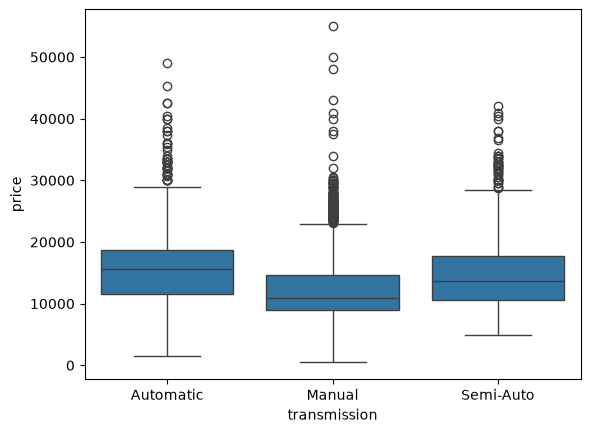

In [119]:
sns.boxplot(data = df, x = 'transmission', y = 'price')

<Axes: xlabel='fuelType', ylabel='price'>

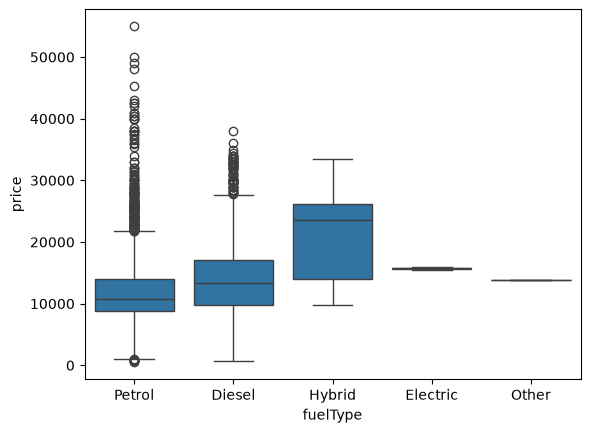

In [120]:
sns.boxplot(data=df, x = 'fuelType', y = 'price')

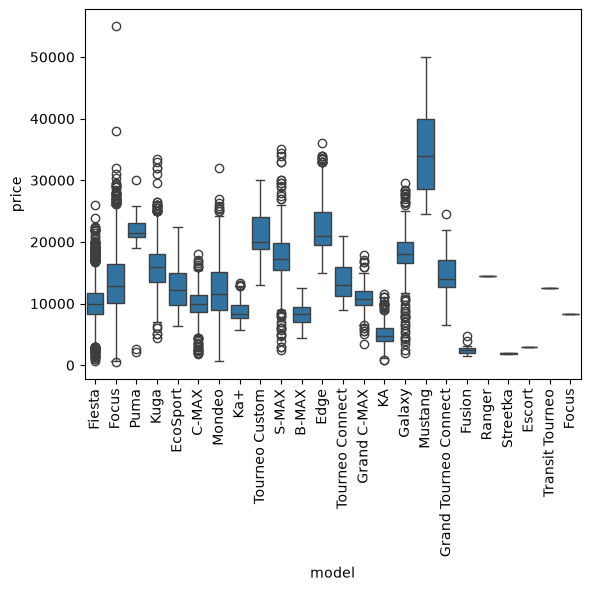

In [121]:
sns.boxplot(data=df, x = 'model', y = 'price')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='tax', ylabel='price'>

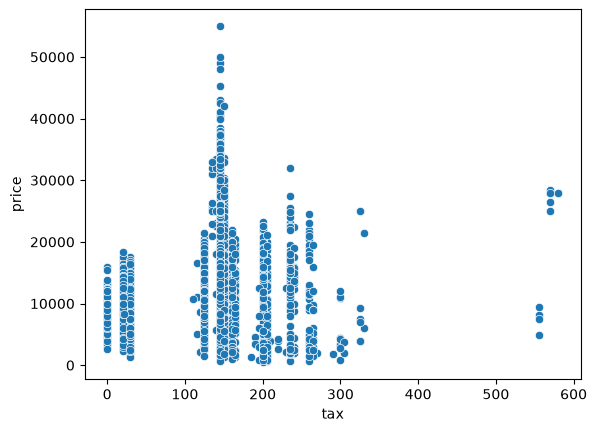

In [122]:
sns.scatterplot(data = df, x='tax',y='price')

<Axes: xlabel='mpg', ylabel='price'>

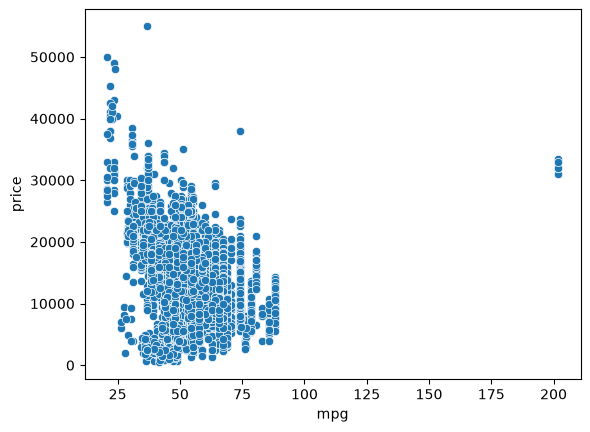

In [123]:
sns.scatterplot(data = df, x='mpg',y='price')

In [124]:
X = df.drop(columns=['price'])
y = df['price']

In [125]:
X.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0


In [126]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

In [127]:
X_one_encoded = pd.get_dummies(X, columns = ['model','transmission','fuelType'], drop_first=True)

In [128]:
X_one_encoded = X_one_encoded.astype(int)

In [129]:
X_one_encoded.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [130]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columns = ['model', 'transmission', 'fuelType']

X_label = X.copy()   # Creates a separate copy

for col in columns:
    X_label[col] = encoder.fit_transform(X_label[col])

print(X_label.head())

   model  year  transmission  mileage  fuelType  tax   mpg  engineSize
0      5  2017             0    15944         4  150  57.7         1.0
1      6  2018             1     9083         4  150  57.7         1.0
2      6  2017             1    12456         4  150  57.7         1.0
3      5  2019             1    10460         4  145  40.3         1.5
4      5  2019             0     1482         4  145  48.7         1.0


In [131]:
X_label.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [132]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

In [133]:
scaler = StandardScaler()
X_one_encoded[numerical_cols] = scaler.fit_transform(X_one_encoded[numerical_cols])